In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor # SGDRegressor is a linear model that uses stochastic gradient descent to optimize the loss function. It is particularly useful for large datasets and can handle online learning scenarios.
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score


def predict(m,X_train,X_test,y_train,y_test):
    name,model = m
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    
    y_test_pred = model.predict(X_test)
    
    print(f"Training Report")
    print(f"Training Error: {mean_absolute_error(y_train, y_train_pred):.2f}")
    print(f"Training Accuracy: {r2_score(y_train,y_train_pred):.2f}")
    
    print("Test Report")
    print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")


house = pd.read_csv("housing.csv")
X = house.drop('median_house_value', axis=1)
y = house.median_house_value

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=121)


num_cols = X.select_dtypes('float').columns
cat_cols = X.select_dtypes('object').columns


num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols)
])

final_pipeline.fit(X_train)
X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)


models = [
    ('linear', LinearRegression()),
    ('SGD', SGDRegressor(max_iter=20000, eta0=0.00001, n_iter_no_change=10)),
    ('forest', RandomForestRegressor()),
    ('KNN', KNeighborsRegressor())
]


for i in models:
    predict(i, X_train_tr,X_test_tr,y_train,y_test)
    print()
    


Model: linear
Training Report
Training Error: 51280.65
Training Accuracy: 0.63
Test Report
Testing Error: 49791.53
Testing Accuracy: 0.66

Model: SGD


e:\App\Anaconda\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training Report
Training Error: 51268.42
Training Accuracy: 0.63
Test Report
Testing Error: 49833.78
Testing Accuracy: 0.65

Model: forest
Training Report
Training Error: 11898.26
Training Accuracy: 0.97
Test Report
Testing Error: 31568.74
Testing Accuracy: 0.82

Model: KNN
Training Report
Training Error: 33173.75
Training Accuracy: 0.81
Test Report
Testing Error: 40837.78
Testing Accuracy: 0.73



### Classification

In [3]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

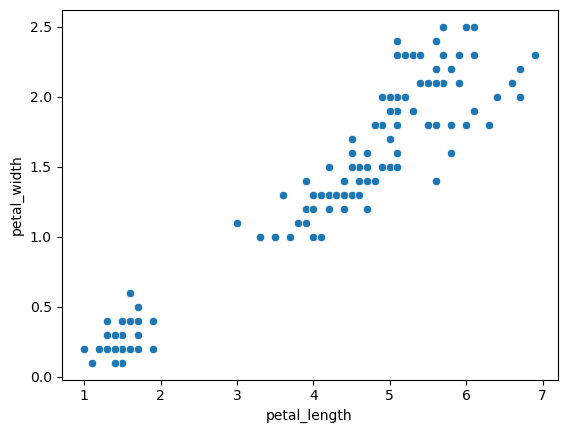

In [4]:
sns.scatterplot(x=iris['petal_length'], y=iris['petal_width'])
plt.show()

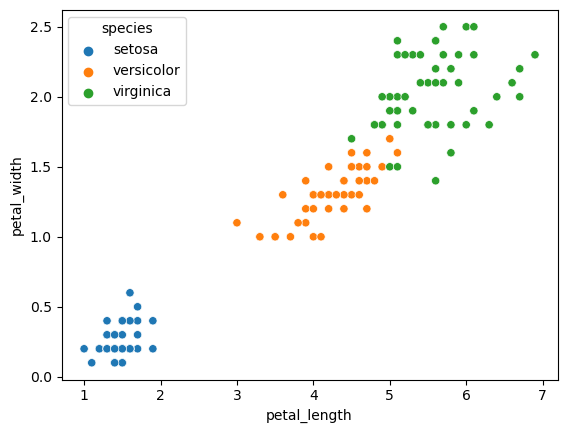

In [5]:
sns.scatterplot(x=iris['petal_length'], y=iris['petal_width'], hue=iris['species'])
plt.show()

In [6]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
X = iris.drop('species', axis=1)
y = iris.species

In [9]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
model = LogisticRegression()
model

LogisticRegression()

In [13]:
model.fit(X,y)

C:\Users\hello\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [14]:
y_pred = model.predict(X)
y_pred

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'virginica'

In [15]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [16]:
y_pred

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'virginica'

In [17]:
y == y_pred

0      True
1      True
2      True
3      True
4      True
       ... 
145    True
146    True
147    True
148    True
149    True
Name: species, Length: 150, dtype: bool

In [18]:
(y == y_pred).sum()


146

In [19]:
((y == y_pred).sum() / len(iris)) * 100


97.33333333333334

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
accuracy_score(y, y_pred)

0.9733333333333334

In [24]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [27]:
y = y == 'setosa'
y

0       True
1       True
2       True
3       True
4       True
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool

In [28]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [29]:
y

0       True
1       True
2       True
3       True
4       True
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool

In [31]:
model = LogisticRegression()
model.fit(X, y)
y_pred = model.predict(X)
y_pred

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [32]:
accuracy_score(y, y_pred)

1.0

In [33]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [34]:
X = iris.drop('species', axis=1)
y = iris.species

In [35]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [36]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [37]:
y.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [38]:
y = y == 'versicolor'
y

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool

In [39]:
model = LogisticRegression()
model.fit(X,y)
y_pred = model.predict(X)
y_pred

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False,  True, False,  True, False, False,  True, False,  True,
       False, False, False, False,  True,  True,  True, False, False,
        True,  True, False, False, False, False, False,  True,  True,
        True, False,  True, False, False, False,  True, False,  True,
        True, False,  True,  True,  True, False, False, False,  True,
       False, False, False, False, False, False, False,  True,  True,
        True, False, False, False, False,  True, False, False, False,
       False,  True,  True, False, False,  True, False, False, False,
       False, False,

In [40]:
accuracy_score(y, y_pred)

0.7266666666666667

In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
confusion_matrix(y, y_pred)

array([[88, 12],
       [29, 21]], dtype=int64)

In [43]:
from sklearn.metrics import classification_report


In [45]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

       False       0.75      0.88      0.81       100
        True       0.64      0.42      0.51        50

    accuracy                           0.73       150
   macro avg       0.69      0.65      0.66       150
weighted avg       0.71      0.73      0.71       150



In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [48]:
y

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool

In [49]:
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
y_pred

array([ 0.12469385,  0.35153271,  0.24437328,  0.33508411,  0.08214759,
       -0.09225932,  0.12990166,  0.19333776,  0.40617118,  0.37846867,
        0.05159141,  0.21943542,  0.40297874,  0.34685482, -0.1563557 ,
       -0.36524739, -0.180527  ,  0.07526319, -0.00431314, -0.03635477,
        0.22941013, -0.0412238 ,  0.00194138,  0.13172588,  0.28563618,
        0.39365119,  0.11654336,  0.1447454 ,  0.16724011,  0.31057404,
        0.3531203 ,  0.08641497, -0.0731937 , -0.19529901,  0.32903801,
        0.21626025,  0.09456545,  0.13359362,  0.33954264,  0.19132239,
        0.05521164,  0.60002799,  0.25041938, -0.02687958,  0.00248225,
        0.30411742,  0.03514281,  0.26845557,  0.05360678,  0.21583247,
        0.35512719,  0.2736549 ,  0.39640736,  0.68137456,  0.47195295,
        0.5648703 ,  0.22581182,  0.64272868,  0.52423728,  0.43767658,
        0.86309366,  0.30665423,  0.86415132,  0.50695038,  0.32372176,
        0.33953416,  0.3789011 ,  0.66744085,  0.72330189,  0.66

In [52]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [53]:
y

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: species, Length: 150, dtype: bool

In [54]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [56]:
sgd = SGDClassifier()
sgd.fit(X,y)
y_pred = sgd.predict(X)

print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Confusion matrix: {confusion_matrix(y, y_pred)}")

Accuracy: 0.6666666666666666
Confusion matrix: [[99  1]
 [49  1]]


In [57]:
forest = RandomForestClassifier()
forest.fit(X,y)
y_pred = forest.predict(X)

print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Confusion matrix: {confusion_matrix(y, y_pred)}")

Accuracy: 1.0
Confusion matrix: [[100   0]
 [  0  50]]


In [58]:
KNN = KNeighborsClassifier()
KNN.fit(X,y)
y_pred = KNN.predict(X)

print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Confusion matrix: {confusion_matrix(y, y_pred)}")

Accuracy: 0.9666666666666667
Confusion matrix: [[98  2]
 [ 3 47]]
